### 1. إعداد المكتبات والإعدادات الأولية (Libraries and Initial Setup)

يتم في هذا القسم استيراد جميع المكتبات اللازمة مثل `pandas` لمعالجة البيانات، و`matplotlib` و`seaborn` للرسوم البيانية، بالإضافة إلى ضبط الإعدادات المرئية للرسومات.

### 2. تحميل البيانات (Data Loading)

في هذا القسم، يتم تحميل مجموعة البيانات من Kaggle Hub إلى DataFrame باستخدام مكتبة `pandas`، مع معالجة أي أخطاء محتملة أثناء التحميل.

In [19]:
import kagglehub
import os
import pandas as pd

print("جاري تحميل البيانات...")
path = kagglehub.dataset_download('vivek468/superstore-dataset-final')
file_path = os.path.join(path, 'Sample - Superstore.csv')

try:
    df = pd.read_csv(file_path, encoding='latin1')
    print("تم تحميل البيانات بنجاح!")
except FileNotFoundError:
    print("لم يتم العثور على الملف، تأكد من المسار.")

جاري تحميل البيانات...
تم تحميل البيانات بنجاح!


In [20]:
df.head ()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 3. تنظيف البيانات وتجهيزها (Data Cleaning & Preprocessing)

يشتمل هذا القسم على خطوات أساسية لمعالجة البيانات لضمان جودتها وجاهزيتها للتحليل، مثل توحيد أسماء الأعمدة، تحويل أنواع البيانات، وإضافة أعمدة جديدة مشتقة.

In [21]:
# توحيد أسماء الأعمدة
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# تحويل التواريخ
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# تحويل الأعمدة الرقمية (لضمان عدم وجود نصوص)
cols_to_numeric = ['sales', 'profit', 'quantity', 'discount']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# إضافة أعمدة جديدة للتحليل
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['profit_margin'] = round((df['profit'] / df['sales']) * 100, 2)
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days

### 4. التحليل والاستنتاجات (Analysis & Visualization)

هذا هو القسم الرئيسي للتحليل، حيث يتم إنشاء رسوم بيانية مختلفة للكشف عن الأنماط والاتجاهات الرئيسية في البيانات، وتتبع كل رسم بياني رؤى وتوصيات محددة.

#### 4.1. نظرة عامة على المبيعات والأرباح سنوياً (Annual Sales and Profit Overview)

عرض إجمالي المبيعات والأرباح لكل عام لتقييم الأداء العام للمتجر.

C:\Users\heba\AppData\Local\Temp\ipykernel_9064\2115566211.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='order_year', y='sales', estimator=sum, errorbar=None, ax=axes[0], palette='Blues_d')
C:\Users\heba\AppData\Local\Temp\ipykernel_9064\2115566211.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='order_year', y='sales', estimator=sum, errorbar=None, ax=axes[0], palette='Blues_d')
C:\Users\heba\AppData\Local\Temp\ipykernel_9064\2115566211.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='order_

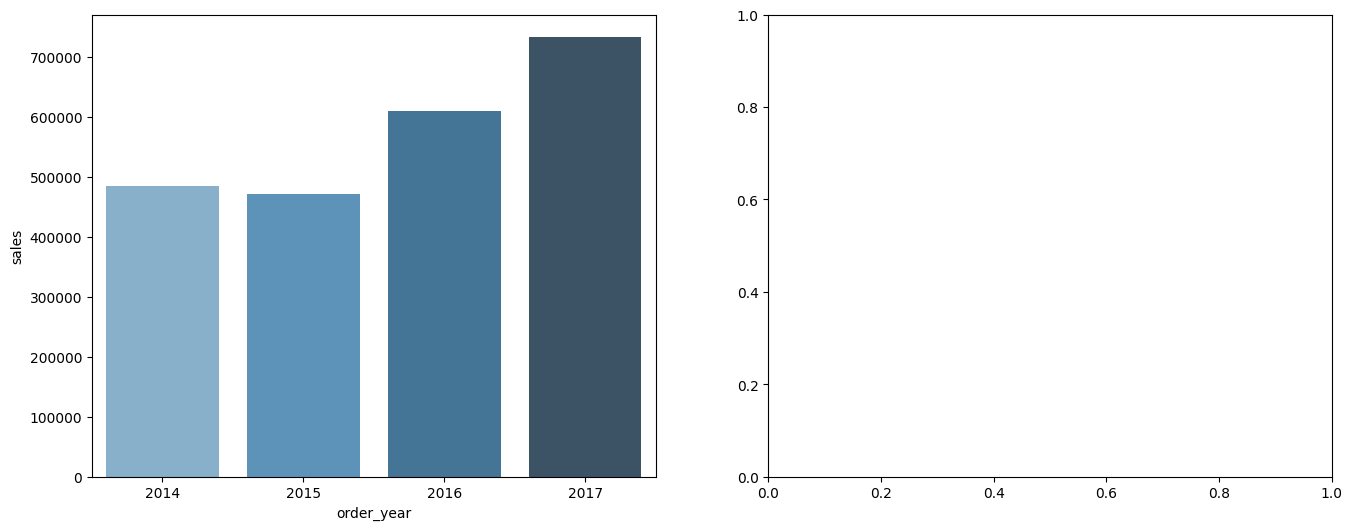

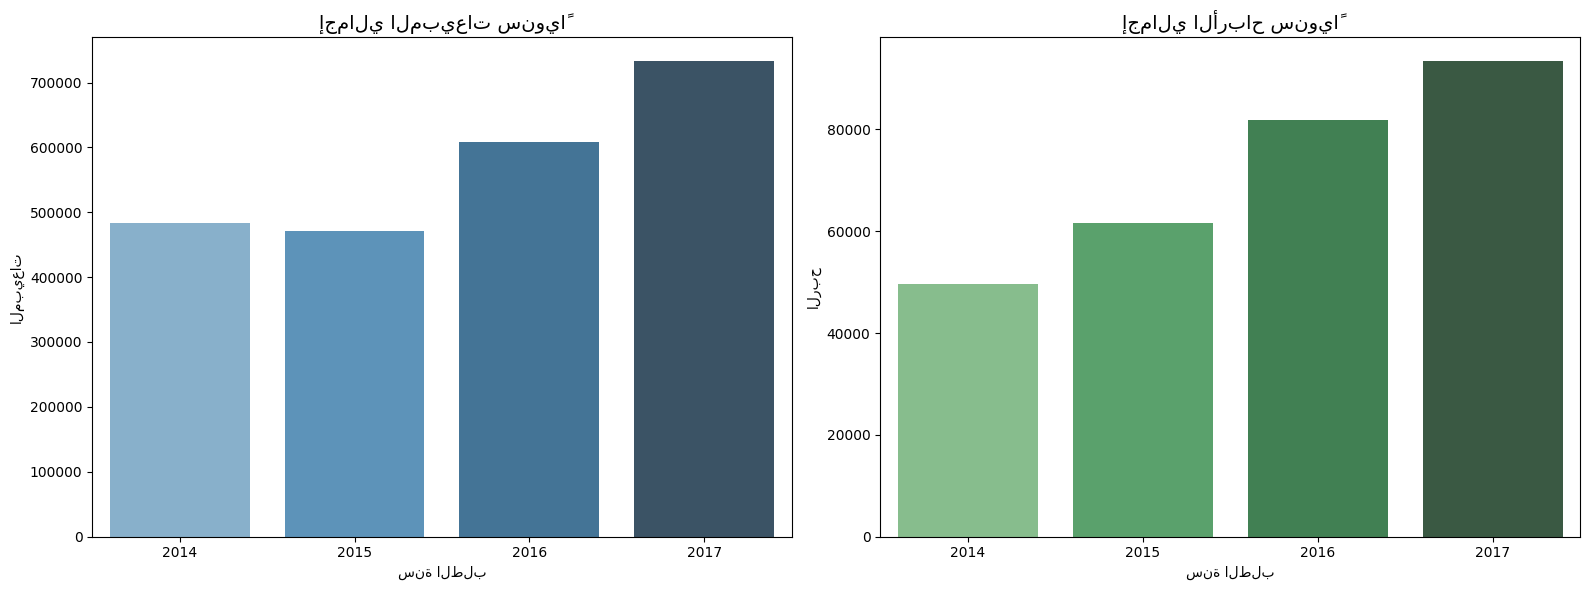


Insight: نمو مستمر في المبيعات، والأرباح تتبع نفس النمط ولكن بهوامش أقل.
Recommendation: يجب فحص التكاليف والخصومات لزيادة هامش الربح في السنوات القادمة.



C:\Users\heba\AppData\Local\Temp\ipykernel_9064\2115566211.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='order_year', y='profit', estimator=sum, errorbar=None, ax=axes[1], palette='Greens_d')


<Figure size 640x480 with 0 Axes>


Insight: نمو مستمر في المبيعات، والأرباح تتبع نفس النمط ولكن بهوامش أقل.
Recommendation: يجب فحص التكاليف والخصومات لزيادة هامش الربح في السنوات القادمة.



In [22]:
import seaborn as sns

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# المبيعات السنوية
sns.barplot(data=df, x='order_year', y='sales', estimator=sum, errorbar=None, ax=axes[0], palette='Blues_d')
import matplotlib.pyplot as plt

def fix_arabic_text(text):
    return text

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# المبيعات السنوية
sns.barplot(data=df, x='order_year', y='sales', estimator=sum, errorbar=None, ax=axes[0], palette='Blues_d')
axes[0].set_title(fix_arabic_text('إجمالي المبيعات سنوياً'), fontsize=14)
axes[0].set_ylabel(fix_arabic_text('المبيعات'))
axes[0].set_xlabel(fix_arabic_text('سنة الطلب')) # إضافة تسمية للمحور X

# الأرباح السنوية
sns.barplot(data=df, x='order_year', y='profit', estimator=sum, errorbar=None, ax=axes[1], palette='Greens_d')
axes[1].set_title(fix_arabic_text('إجمالي الأرباح سنوياً'), fontsize=14)
axes[1].set_ylabel(fix_arabic_text('الربح'))
axes[1].set_xlabel(fix_arabic_text('سنة الطلب')) # إضافة تسمية للمحور X

plt.tight_layout()
plt.show()

print("""
Insight: نمو مستمر في المبيعات، والأرباح تتبع نفس النمط ولكن بهوامش أقل.
Recommendation: يجب فحص التكاليف والخصومات لزيادة هامش الربح في السنوات القادمة.
""")
axes[0].set_ylabel(fix_arabic_text('المبيعات'))
axes[0].set_xlabel(fix_arabic_text('سنة الطلب')) # إضافة تسمية للمحور X

# الأرباح السنوية
sns.barplot(data=df, x='order_year', y='profit', estimator=sum, errorbar=None, ax=axes[1], palette='Greens_d')
axes[1].set_title(fix_arabic_text('إجمالي الأرباح سنوياً'), fontsize=14)
axes[1].set_ylabel(fix_arabic_text('الربح'))
axes[1].set_xlabel(fix_arabic_text('سنة الطلب')) # إضافة تسمية للمحور X

plt.tight_layout()
plt.show()

print("""
Insight: نمو مستمر في المبيعات، والأرباح تتبع نفس النمط ولكن بهوامش أقل.
Recommendation: يجب فحص التكاليف والخصومات لزيادة هامش الربح في السنوات القادمة.
""")

**Insight:** نمو مستمر في المبيعات، والأرباح تتبع نفس النمط ولكن بهوامش أقل.

**Recommendation:** يجب فحص التكاليف والخصومات لزيادة هامش الربح في السنوات القادمة.

#### 4.2. تحليل الفئات الفرعية (Sub-Category Analysis)

تحليل الربح والخسارة لكل فئة فرعية لتحديد المنتجات ذات الأداء الجيد وتلك التي تحتاج إلى مراجعة.

C:\Users\heba\AppData\Local\Temp\ipykernel_9064\1977970442.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_cat_analysis, y='sub-category', x='profit', palette='coolwarm')


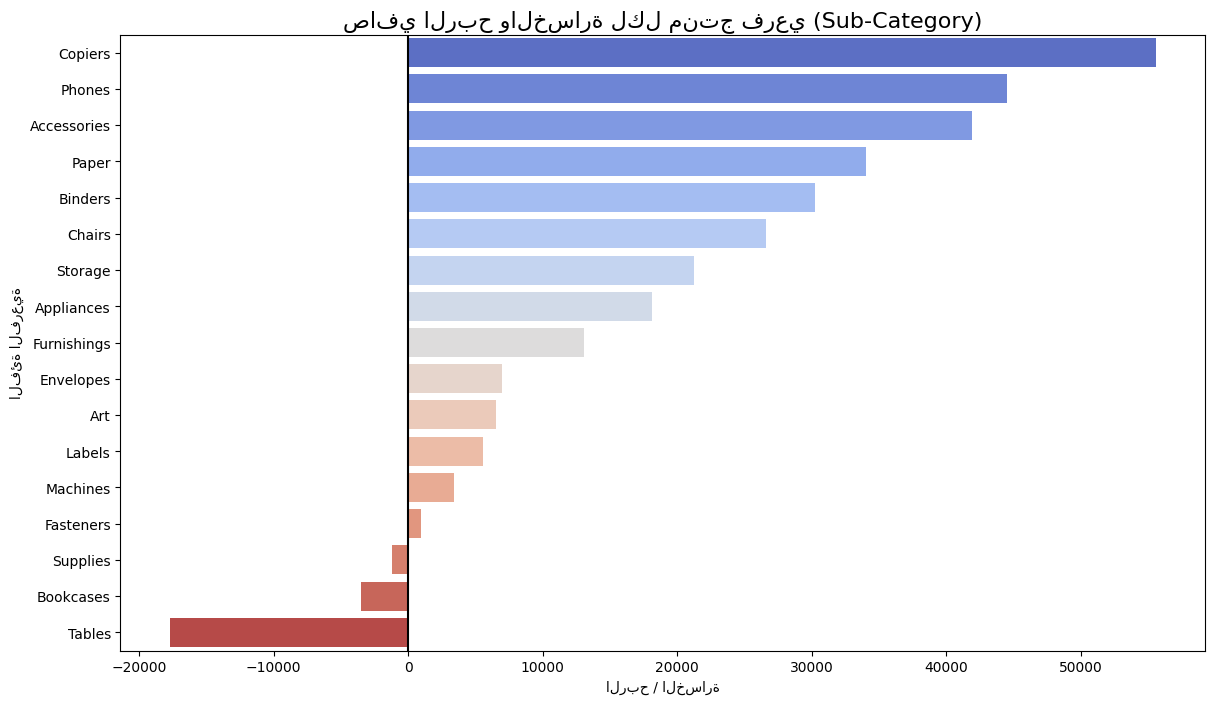


*** تحليل عميق (Deep Dive) ***:
Insight: نلاحظ أن فئة "Tables" (الطاولات) و "Bookcases" (المكتبات) تحقق خسائر صافية رغم أنها تابعة لفئة الأثاث!
Recommendation: يجب وقف الخصومات فوراً على الطاولات، أو إعادة تسعيرها، أو حتى التفكير في إيقاف بيعها إذا استمرت الخسارة.



In [23]:
plt.figure(figsize=(14, 8))
sub_cat_analysis = df.groupby('sub-category')[['sales', 'profit']].sum().sort_values('profit', ascending=False).reset_index()

# تطبيق fix_arabic_text على أسماء الفئات الفرعية
sub_cat_analysis['sub-category'] = sub_cat_analysis['sub-category'].apply(fix_arabic_text)

sns.barplot(data=sub_cat_analysis, y='sub-category', x='profit', palette='coolwarm')
plt.title(fix_arabic_text('صافي الربح والخسارة لكل منتج فرعي (Sub-Category)'), fontsize=16)
plt.axvline(x=0, color='black', linestyle='-')
plt.xlabel(fix_arabic_text('الربح / الخسارة'))
plt.ylabel(fix_arabic_text('الفئة الفرعية')) # إضافة تسمية للمحور Y
plt.show()

print("""
*** تحليل عميق (Deep Dive) ***:
Insight: نلاحظ أن فئة "Tables" (الطاولات) و "Bookcases" (المكتبات) تحقق خسائر صافية رغم أنها تابعة لفئة الأثاث!
Recommendation: يجب وقف الخصومات فوراً على الطاولات، أو إعادة تسعيرها، أو حتى التفكير في إيقاف بيعها إذا استمرت الخسارة.
""")

*** تحليل عميق (Deep Dive) ***

Insight: نلاحظ أن فئة "Tables" (الطاولات) و "Bookcases" (المكتبات) تحقق خسائر صافية رغم أنها تابعة لفئة الأثاث!

Recommendation: يجب وقف الخصومات فوراً على الطاولات، أو إعادة تسعيرها، أو حتى التفكير في إيقاف بيعها إذا استمرت الخسارة.

#### 4.3. تأثير الخصم على الربحية (Impact of Discount on Profitability)

فحص العلاقة بين نسبة الخصم والأرباح لتحديد النسبة المثلى للخصم التي لا تؤدي إلى خسائر.

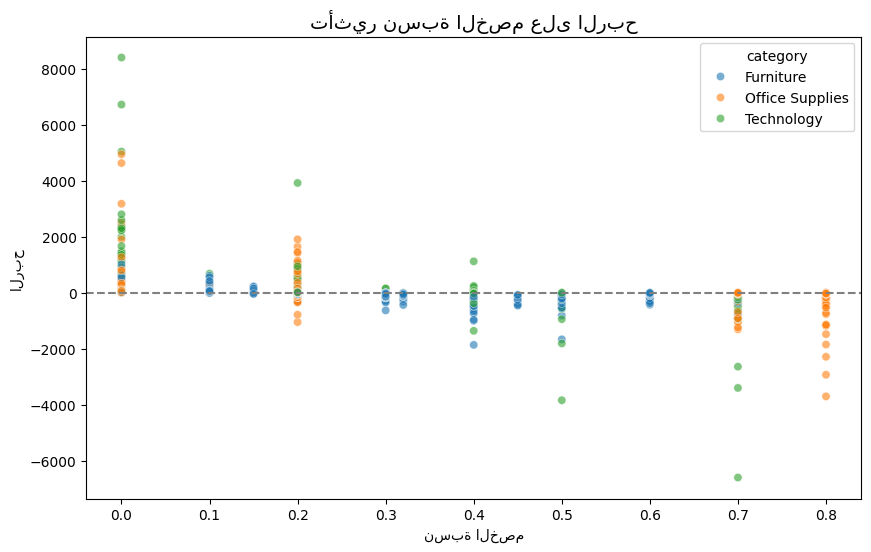


Insight: بمجرد أن يتجاوز الخصم 20%، تبدأ الأرباح في التحول إلى خسائر (تحت الخط الرمادي).
Recommendation: وضع حد أقصى للخصم لا يتجاوز 20% إلا في حالات التصفية القصوى.



In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount', y='profit', hue='category', alpha=0.6)
plt.axhline(0, color='grey', linestyle='--')
plt.title(fix_arabic_text('تأثير نسبة الخصم على الربح'), fontsize=14)
plt.xlabel(fix_arabic_text('نسبة الخصم')) # إضافة تسمية للمحور X
plt.ylabel(fix_arabic_text('الربح')) # إضافة تسمية للمحور Y
plt.show()

print("""
Insight: بمجرد أن يتجاوز الخصم 20%، تبدأ الأرباح في التحول إلى خسائر (تحت الخط الرمادي).
Recommendation: وضع حد أقصى للخصم لا يتجاوز 20% إلا في حالات التصفية القصوى.
""")

Insight: بمجرد أن يتجاوز الخصم 20%، تبدأ الأرباح في التحول إلى خسائر (تحت الخط الرمادي).

Recommendation: وضع حد أقصى للخصم لا يتجاوز 20% إلا في حالات التصفية القصوى.

#### 4.4. أفضل وأسوأ الولايات ربحية (Top and Bottom States by Profitability)

تحديد الولايات التي تساهم بشكل أكبر في الأرباح وتلك التي تتسبب في خسائر لدراسة الأداء الإقليمي.

C:\Users\heba\AppData\Local\Temp\ipykernel_9064\2722561485.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom_states, x='state', y='profit', palette='RdYlGn')


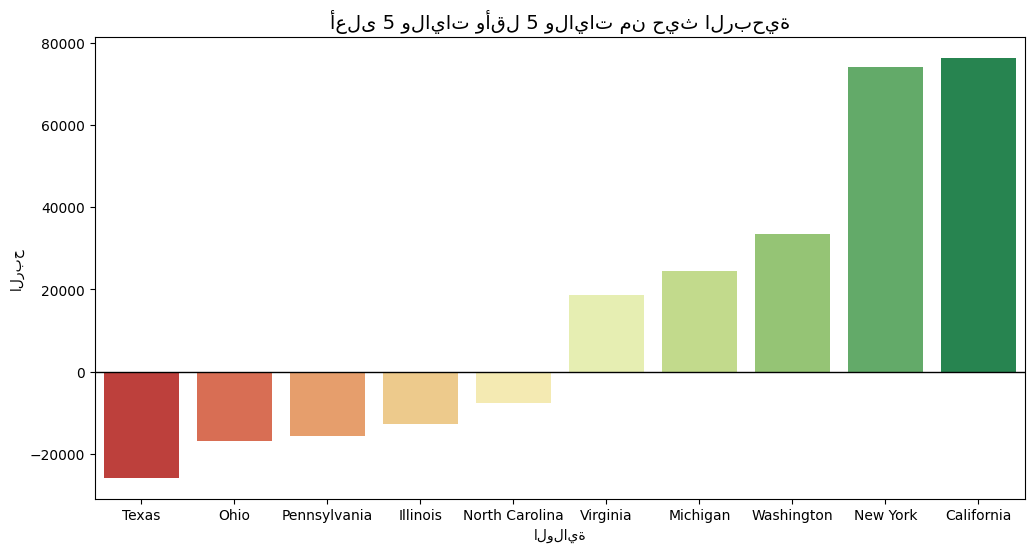


Insight: ولايات مثل California و New York هي محرك الربح، بينما Texas و Ohio تحقق خسائر ضخمة.
Recommendation: يجب دراسة تكاليف الشحن أو سياسة التسعير في تكساس وأوهايو بشكل خاص.



In [25]:
state_profit = df.groupby('state')['profit'].sum().sort_values().reset_index()

# نأخذ أعلى 5 وأقل 5
top_bottom_states = pd.concat([state_profit.head(5), state_profit.tail(5)])

# تطبيق fix_arabic_text على أسماء الولايات
top_bottom_states['state'] = top_bottom_states['state'].apply(fix_arabic_text)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_bottom_states, x='state', y='profit', palette='RdYlGn')
plt.title(fix_arabic_text('أعلى 5 ولايات وأقل 5 ولايات من حيث الربحية'), fontsize=14)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel(fix_arabic_text('الولاية')) # إضافة تسمية للمحور X
plt.ylabel(fix_arabic_text('الربح')) # إضافة تسمية للمحور Y
plt.show()

print("""
Insight: ولايات مثل California و New York هي محرك الربح، بينما Texas و Ohio تحقق خسائر ضخمة.
Recommendation: يجب دراسة تكاليف الشحن أو سياسة التسعير في تكساس وأوهايو بشكل خاص.
""")

Insight: California و New York هي محرك الربح ، Texas و Ohio  تحقق خسائر ضخمة.

Recommendation: يجب دراسة تكاليف الشحن أو سياسة التسعير في تكساس وأوهايو بشكل خاص.

#### 4.5. مصفوفة الارتباط بين المتغيرات (Correlation Heatmap)

تصور العلاقات الارتباطية بين المتغيرات الرقمية الرئيسية، مثل المبيعات والأرباح والكمية والخصم، لفهم كيفية تأثيرها على بعضها البعض.

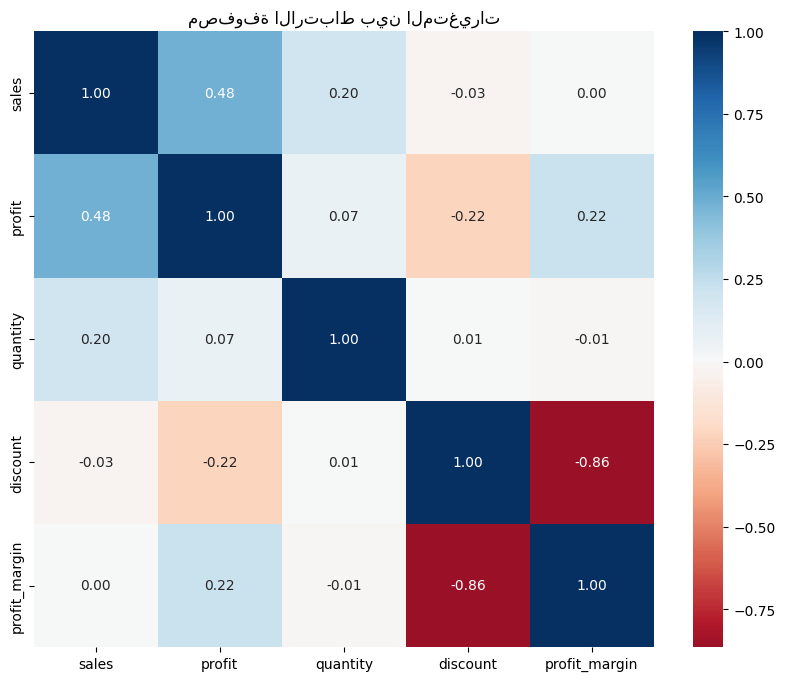

In [26]:
plt.figure(figsize=(10, 8))
corr_cols = ['sales', 'profit', 'quantity', 'discount', 'profit_margin']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title(fix_arabic_text("مصفوفة الارتباط بين المتغيرات"))
plt.show()